In [1]:
import pandas as pd
df=pd.read_csv("supermarket_sales_data.csv")
print("Dataset loaded successfully!")
print("Rows:",len(df))
print("Columns:",len(df.columns))


Dataset loaded successfully!
Rows: 500
Columns: 13


In [2]:
df.head()


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.8,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.9,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.4,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.5,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.1,652.85


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice ID     500 non-null    str    
 1   Date           500 non-null    str    
 2   Branch         500 non-null    str    
 3   City           500 non-null    str    
 4   Customer Type  500 non-null    str    
 5   Gender         500 non-null    str    
 6   Product        500 non-null    str    
 7   Category       500 non-null    str    
 8   Quantity       500 non-null    int64  
 9   Unit Price     500 non-null    float64
 10  Payment        500 non-null    str    
 11  Rating         500 non-null    float64
 12  Sales          500 non-null    float64
dtypes: float64(3), int64(1), str(9)
memory usage: 50.9 KB


In [4]:
df.isnull().sum()

Invoice ID       0
Date             0
Branch           0
City             0
Customer Type    0
Gender           0
Product          0
Category         0
Quantity         0
Unit Price       0
Payment          0
Rating           0
Sales            0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["Calculated Sales"] = df["Quantity"] * df["Unit Price"]

df["Sales Check"] = (
    df["Sales"].round(2) == df["Calculated Sales"].round(2)
)

print("Incorrect Sales values:", (~df["Sales Check"]).sum())

Incorrect Sales values: 0


In [7]:
df.describe()


,Quantity,Unit Price,Rating,Sales,Calculated Sales
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5.536000,88.660700,3.994400,488.822160,488.822160
std,2.875629,57.284029,0.574481,437.327833,437.327833
min,1.000000,27.670000,3.000000,28.610000,28.610000
25%,3.000000,43.955000,3.500000,189.212500,189.212500
50%,5.500000,61.880000,4.000000,335.910000,335.910000
75%,8.000000,128.567500,4.500000,609.885000,609.885000
max,10.000000,236.710000,5.000000,2114.820000,2114.820000


In [8]:
total_sales = df["Sales"].sum()
print("Total Sales:",round(total_sales,2))

Total Sales: 244411.08


In [9]:
total_quantity=df["Quantity"].sum()
print("Total Quantity Sold:",total_quantity)

Total Quantity Sold: 2768


In [10]:
print("Average Sales:",round(df["Sales"].mean(),2))
print("Maximum Sale:",round(df["Sales"].max(),2))
print("Minimum Sale:",round(df["Sales"].min(),2))
print("Average Quantity:",round(df["Quantity"].mean(),2))
print("Average Rating:",round(df["Rating"].mean(),2))





Average Sales: 488.82
Maximum Sale: 2114.82
Minimum Sale: 28.61
Average Quantity: 5.54
Average Rating: 3.99


In [11]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

print("Product-wise Sales:")
print(product_sales)

print("\nHighest-selling Product:", product_sales.idxmax())
print("Highest Product Sales:", round(product_sales.max(), 2))

Product-wise Sales:
Product
Cheese         27906.30
Coffee         27694.87
Shampoo        27497.48
Cooking Oil    21525.06
Tea            17681.59
Apples         17057.41
Face Wash      11946.85
Rice           11754.17
Cold Drink     10731.78
Eggs           10429.77
Chocolate       7250.65
Noodles         7191.24
Potato          6799.38
Bread           6516.10
Soap            6499.63
Bananas         6205.76
Chips           5833.45
Milk            5655.93
Tomato          4324.79
Biscuits        3908.87
Name: Sales, dtype: float64

Highest-selling Product: Cheese
Highest Product Sales: 27906.3


In [12]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print("Category-wise Sales:")
print(category_sales)

print("\nHighest-selling Category:", category_sales.idxmax())
print("Highest Category Sales:", round(category_sales.max(), 2))

Category-wise Sales:
Category
Beverages        56108.24
Personal Care    45943.96
Dairy            43992.00
Grocery          40470.47
Fruits           23263.17
Snacks           16992.97
Vegetables       11124.17
Bakery            6516.10
Name: Sales, dtype: float64

Highest-selling Category: Beverages
Highest Category Sales: 56108.24


In [13]:
branch_sales = df.groupby(["Branch", "City"])["Sales"].sum().sort_values(ascending=False)

print("Branch-wise Sales:")
print(branch_sales)

print("\nBest Branch:", branch_sales.idxmax())
print("Best Branch Sales:", round(branch_sales.max(), 2))

Branch-wise Sales:
Branch  City     
C       Mumbai       72469.45
B       Delhi        64116.26
D       Bengaluru    55468.29
A       Jaipur       52357.08
Name: Sales, dtype: float64

Best Branch: ('C', 'Mumbai')
Best Branch Sales: 72469.45


In [14]:
payment_counts = df["Payment"].value_counts()

print("Payment Method Usage:")
print(payment_counts)

print("\nMost-used Payment Method:", payment_counts.idxmax())
print("Number of Transactions:", payment_counts.max())

Payment Method Usage:
Payment
UPI            127
Net Banking    126
Card           125
Cash           122
Name: count, dtype: int64

Most-used Payment Method: UPI
Number of Transactions: 127


In [15]:
customer_sales = df.groupby("Customer Type")["Sales"].mean().round(2)

print("Average Sales by Customer Type:")
print(customer_sales)

print("\nHighest Spending Customer Type:", customer_sales.idxmax())
print("Average Spending:", round(customer_sales.max(), 2))

Average Sales by Customer Type:
Customer Type
Member    483.14
Normal    497.07
Name: Sales, dtype: float64

Highest Spending Customer Type: Normal
Average Spending: 497.07


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


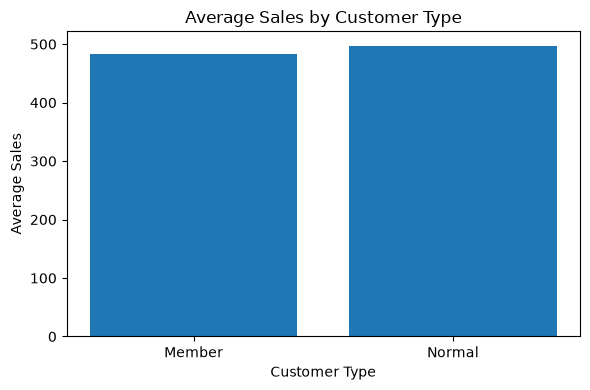

In [17]:
plt.figure(figsize=(6, 4))
plt.bar(customer_sales.index, customer_sales.values)
plt.title("Average Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

In [18]:
gender_sales = df.groupby("Gender")["Sales"].mean()

print("Average Sales by Gender:")
print(gender_sales)

Average Sales by Gender:
Gender
Female    486.094588
Male      491.661061
Name: Sales, dtype: float64


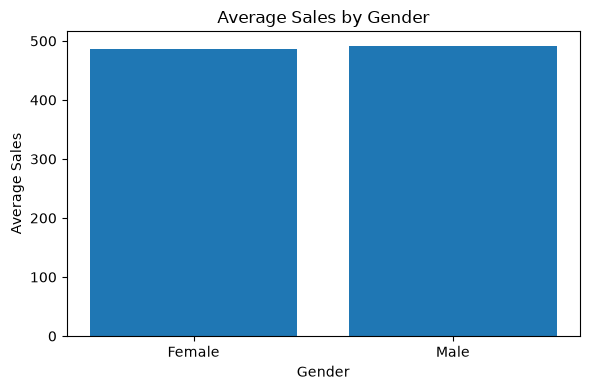

In [19]:
plt.figure(figsize=(6,4))

plt.bar(gender_sales.index, gender_sales.values)

plt.title("Average Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

In [20]:
rating_counts = df["Rating"].value_counts().sort_index()

print("Rating Distribution:")
print(rating_counts)

Rating Distribution:
Rating
3.0     8
3.1    24
3.2    33
3.3    24
3.4    24
3.5    31
3.6    25
3.7    14
3.8    28
3.9    23
4.0    28
4.1    30
4.2    25
4.3    30
4.4    14
4.5    33
4.6    26
4.7    20
4.8    23
4.9    21
5.0    16
Name: count, dtype: int64


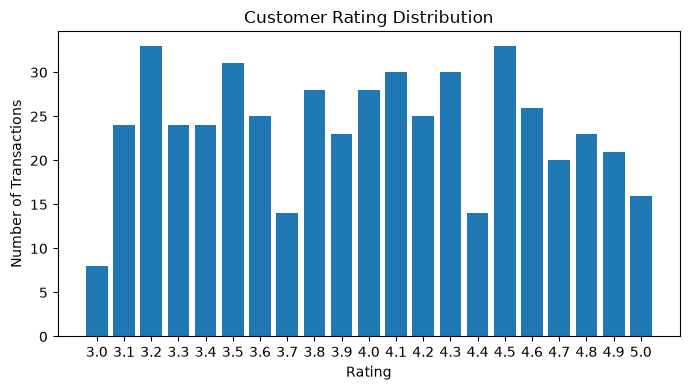

In [21]:
plt.figure(figsize=(7,4))

plt.bar(rating_counts.index.astype(str), rating_counts.values)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [22]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

print("Sales by Product:")
print(product_sales)

Sales by Product:
Product
Cheese         27906.30
Coffee         27694.87
Shampoo        27497.48
Cooking Oil    21525.06
Tea            17681.59
Apples         17057.41
Face Wash      11946.85
Rice           11754.17
Cold Drink     10731.78
Eggs           10429.77
Chocolate       7250.65
Noodles         7191.24
Potato          6799.38
Bread           6516.10
Soap            6499.63
Bananas         6205.76
Chips           5833.45
Milk            5655.93
Tomato          4324.79
Biscuits        3908.87
Name: Sales, dtype: float64


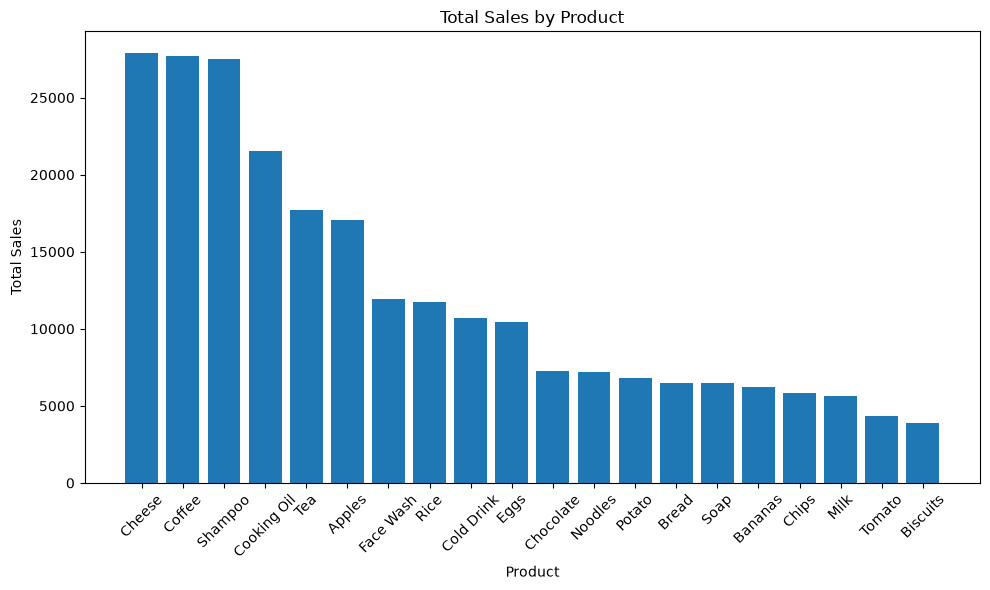

In [23]:
plt.figure(figsize=(10, 6))

plt.bar(product_sales.index, product_sales.values)

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
highest_product = product_sales.idxmax()
highest_sales = product_sales.max()

print("Highest-selling Product:", highest_product)
print("Total Sales:", highest_sales)

Highest-selling Product: Cheese
Total Sales: 27906.3


In [25]:
branch_sales = df.groupby("Branch")["Sales"].sum().sort_values(ascending=False)

print("Sales by Branch:")
print(branch_sales)

Sales by Branch:
Branch
C    72469.45
B    64116.26
D    55468.29
A    52357.08
Name: Sales, dtype: float64


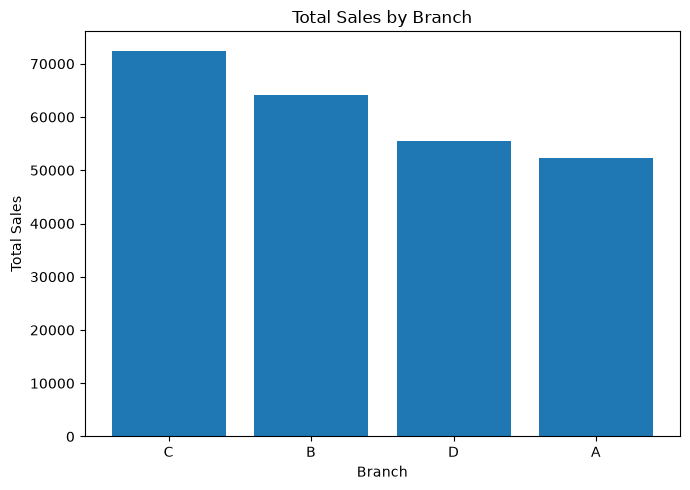

In [26]:
plt.figure(figsize=(7, 5))

plt.bar(branch_sales.index, branch_sales.values)

plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [27]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print("Sales by Category:")
print(category_sales)

Sales by Category:
Category
Beverages        56108.24
Personal Care    45943.96
Dairy            43992.00
Grocery          40470.47
Fruits           23263.17
Snacks           16992.97
Vegetables       11124.17
Bakery            6516.10
Name: Sales, dtype: float64


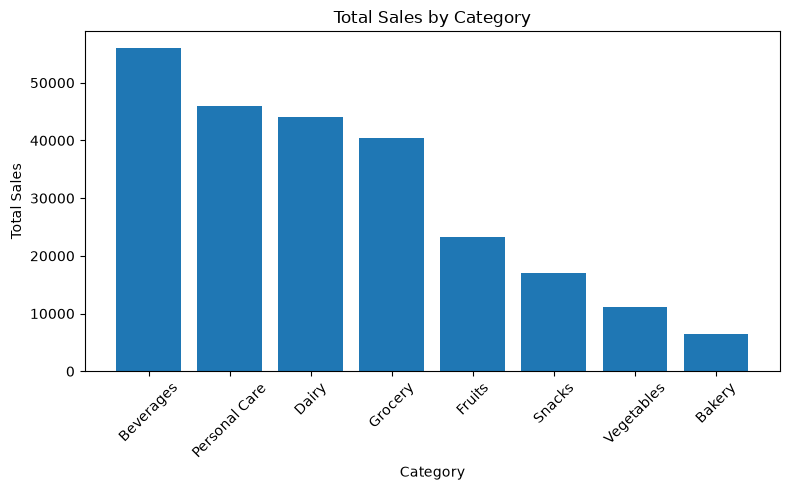

In [28]:
plt.figure(figsize=(8, 5))

plt.bar(category_sales.index, category_sales.values)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
payment_sales = df.groupby("Payment")["Sales"].sum().sort_values(ascending=False)

print("Sales by Payment Method:")
print(payment_sales)

Sales by Payment Method:
Payment
UPI            67910.33
Net Banking    65194.93
Card           57265.64
Cash           54040.18
Name: Sales, dtype: float64


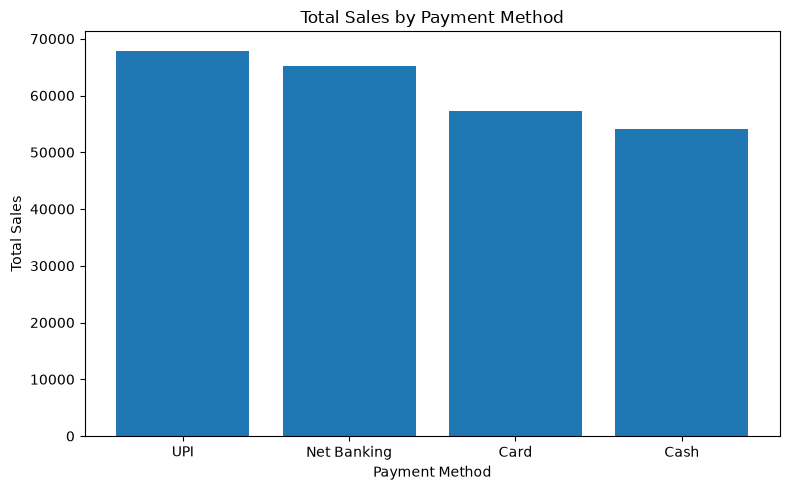

In [30]:
plt.figure(figsize=(8, 5))

plt.bar(payment_sales.index, payment_sales.values)

plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()


In [31]:
customer_type_sales = df.groupby("Customer Type")["Sales"].mean()

print("Average Sales by Customer Type:")
print(customer_type_sales)

Average Sales by Customer Type:
Customer Type
Member    483.139527
Normal    497.067549
Name: Sales, dtype: float64


In [32]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (500, 15)

Missing Values:
Invoice ID          0
Date                0
Branch              0
City                0
Customer Type       0
Gender              0
Product             0
Category            0
Quantity            0
Unit Price          0
Payment             0
Rating              0
Sales               0
Calculated Sales    0
Sales Check         0
dtype: int64

Duplicate Rows: 0

Data Types:
Invoice ID              str
Date                    str
Branch                  str
City                    str
Customer Type           str
Gender                  str
Product                 str
Category                str
Quantity              int64
Unit Price          float64
Payment                 str
Rating              float64
Sales               float64
Calculated Sales    float64
Sales Check            bool
dtype: object


In [33]:
print("Total Sales:", df["Sales"].sum())
print("Total Transactions:", df["Invoice ID"].count())
print("Average Sales per Transaction:", df["Sales"].mean())
print("Average Customer Rating:", df["Rating"].mean())
print("Total Quantity Sold:", df["Quantity"].sum())

Total Sales: 244411.08000000002
Total Transactions: 500
Average Sales per Transaction: 488.82216000000005
Average Customer Rating: 3.9943999999999997
Total Quantity Sold: 2768


In [34]:
print("Average Customer Rating:", df["Rating"].mean())
print("Highest Rating:", df["Rating"].max())
print("Lowest Rating:", df["Rating"].min())

Average Customer Rating: 3.9943999999999997
Highest Rating: 5.0
Lowest Rating: 3.0


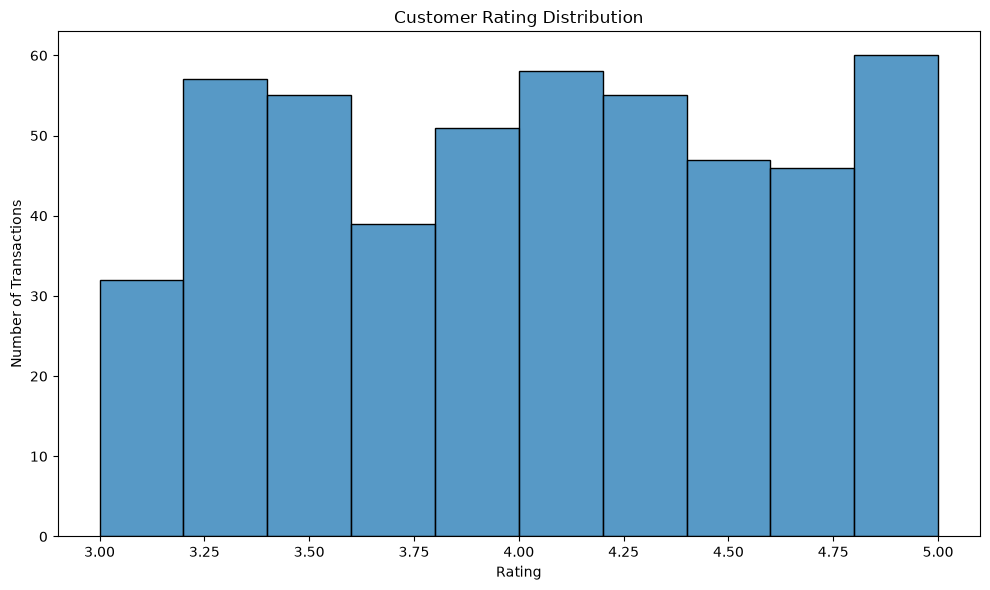

In [35]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Rating"], bins=10, kde=False)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

## Business Recommendations

1. Focus on Cheese, Coffee, and Shampoo because they generate high sales.

2. Study the strategies used by Branch C and apply successful practices to lower-performing branches.

3. Promote Beverages because it is the highest-selling category.

4. Encourage UPI and Net Banking payments since they generate strong sales.

5. Improve customer experience to maintain the overall rating close to 4 out of 5.

6. Analyze Normal customers because their average transaction value is slightly higher than Member customers.

7. Use customer ratings to identify areas where product quality and service can be improved.